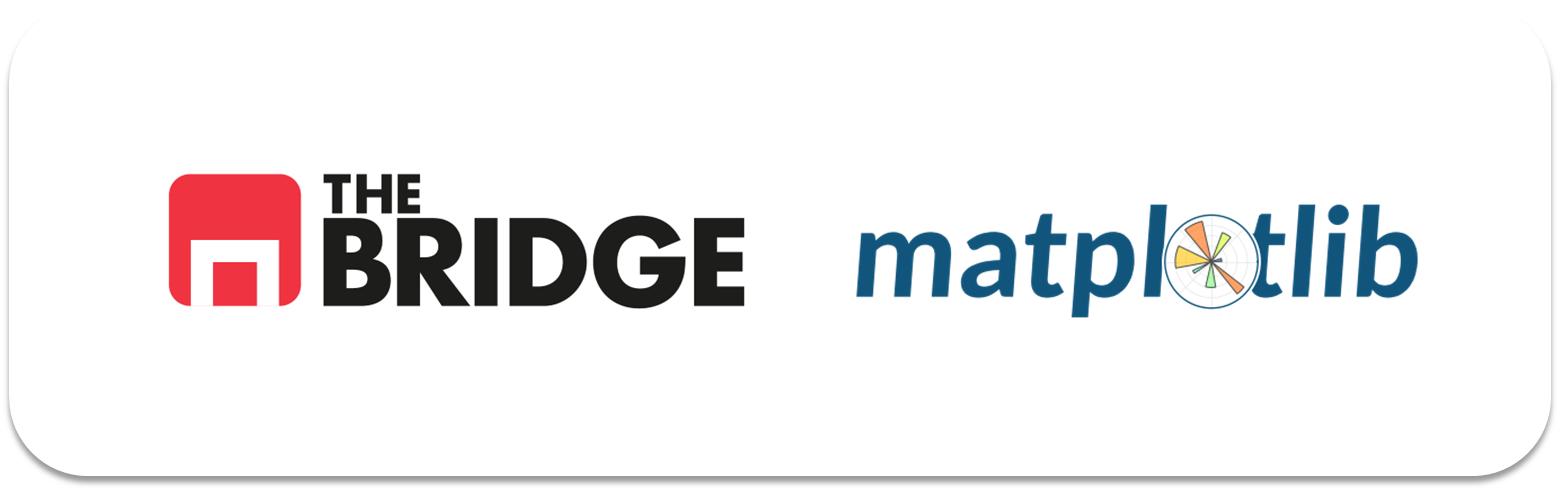

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [28]:
df = pd.read_csv("./data/california_cities.csv")

df.head()


,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
2,2,Alameda,37.756111,-122.274444,NaN,33.0,75467,22.960,10.611,12.349,59.465,27.482,31.983,53.79
3,3,Albany,37.886944,-122.297778,NaN,43.0,18969,5.465,1.788,3.677,14.155,4.632,9.524,67.28
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01


In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          482 non-null    int64  
 1   city                482 non-null    object 
 2   latd                482 non-null    float64
 3   longd               482 non-null    float64
 4   elevation_m         434 non-null    float64
 5   elevation_ft        470 non-null    float64
 6   population_total    482 non-null    int64  
 7   area_total_sq_mi    480 non-null    float64
 8   area_land_sq_mi     482 non-null    float64
 9   area_water_sq_mi    481 non-null    float64
 10  area_total_km2      477 non-null    float64
 11  area_land_km2       478 non-null    float64
 12  area_water_km2      478 non-null    float64
 13  area_water_percent  477 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 52.8+ KB


In [30]:
df = df.dropna()
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 427 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          427 non-null    int64  
 1   city                427 non-null    object 
 2   latd                427 non-null    float64
 3   longd               427 non-null    float64
 4   elevation_m         427 non-null    float64
 5   elevation_ft        427 non-null    float64
 6   population_total    427 non-null    int64  
 7   area_total_sq_mi    427 non-null    float64
 8   area_land_sq_mi     427 non-null    float64
 9   area_water_sq_mi    427 non-null    float64
 10  area_total_km2      427 non-null    float64
 11  area_land_km2       427 non-null    float64
 12  area_water_km2      427 non-null    float64
 13  area_water_percent  427 non-null    float64
dtypes: float64(11), int64(2), object(1)
memory usage: 50.0+ KB


In [31]:
df.columns

Index(['Unnamed: 0', 'city', 'latd', 'longd', 'elevation_m', 'elevation_ft',
       'population_total', 'area_total_sq_mi', 'area_land_sq_mi',
       'area_water_sq_mi', 'area_total_km2', 'area_land_km2', 'area_water_km2',
       'area_water_percent'],
      dtype='object')

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center"). (Colores: azul, gris, aceituna, marrón, con trasparencia)  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Bradley Hand ITC", tamaño 18, color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion.
4. El boxplot de la altura de las ciudades.

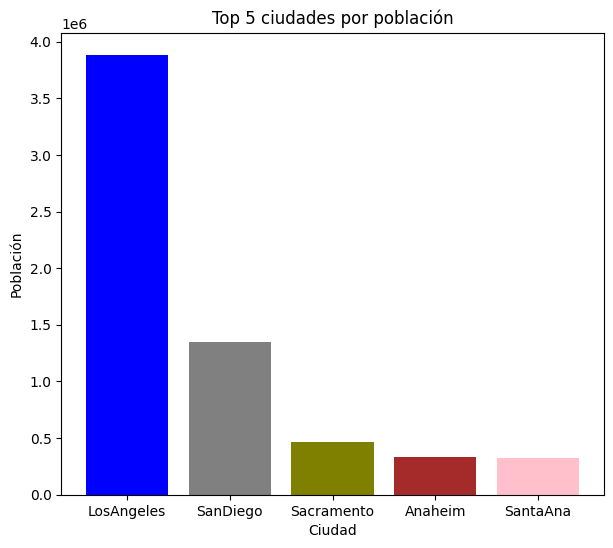

In [32]:
top5 = df.nlargest(5, "population_total")[["city", "population_total"]]
colores = ["blue", "gray", "olive", "brown", "pink"]

plt.figure(figsize=(7,6))
plt.bar(top5["city"], top5["population_total"], color=colores)
plt.title("Top 5 ciudades por población")
plt.xlabel("Ciudad")
plt.ylabel("Población")
plt.show()


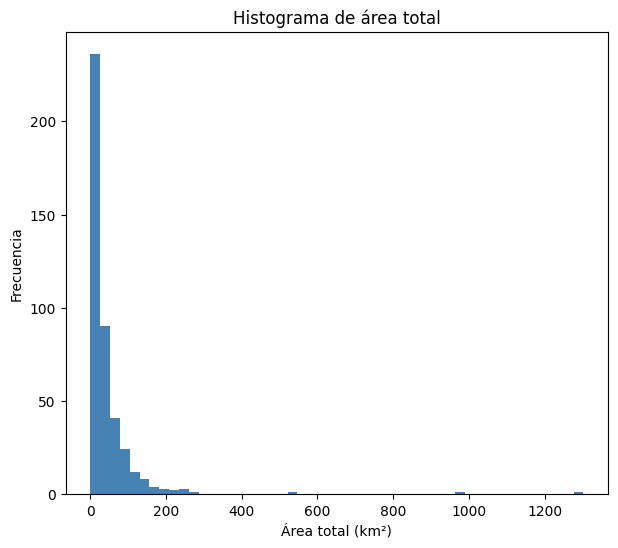

In [33]:
plt.figure(figsize=(7,6))
plt.hist(df["area_total_km2"], bins=50, color="steelblue")
plt.title("Histograma de área total")
plt.xlabel("Área total (km²)")
plt.ylabel("Frecuencia")
plt.show()


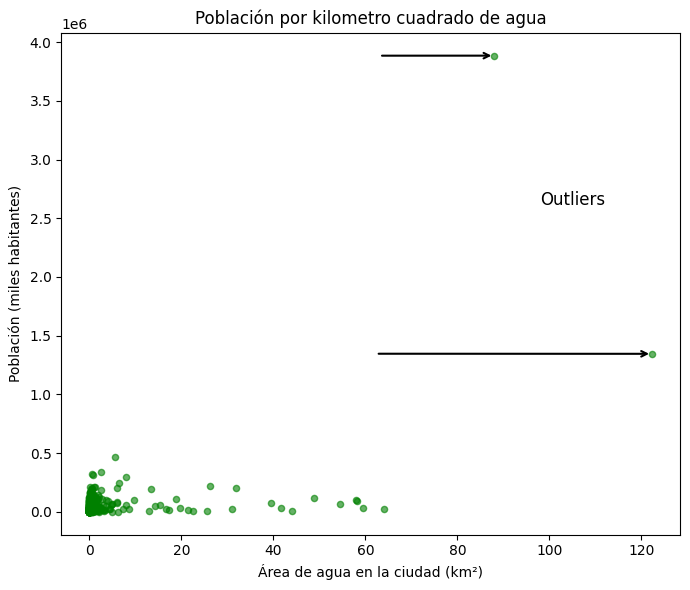

In [34]:
plt.figure(figsize=(7,6))
plt.scatter(df["area_water_km2"], df["population_total"], s=20, color="green", alpha=0.6)

plt.xlabel("Área de agua en la ciudad (km²)")
plt.ylabel("Población (miles habitantes)")
plt.title("Población por kilometro cuadrado de agua")

punto_alto = df.loc[df["population_total"].idxmax()]
punto_derecha = df.loc[df["area_water_km2"].idxmax()]

plt.text(
    x = (punto_alto["area_water_km2"] + punto_derecha["area_water_km2"]) / 2,
    y = (punto_alto["population_total"] + punto_derecha["population_total"]) / 2 + 200,
    s = "Outliers",
    ha = "center",
    fontsize = 12
)

plt.annotate(
    "",
    xy = (punto_alto["area_water_km2"], punto_alto["population_total"]),
    xytext = (punto_alto["area_water_km2"] - 25, punto_alto["population_total"] - 300),
    arrowprops = dict(arrowstyle="->", color="black", lw=1.5)
)

plt.annotate(
    "",
    xy = (punto_derecha["area_water_km2"], punto_derecha["population_total"]),
    xytext = (punto_derecha["area_water_km2"] - 60, punto_derecha["population_total"] + 700),
    arrowprops = dict(arrowstyle="->", color="black", lw=1.5)
)

plt.tight_layout()
plt.show()


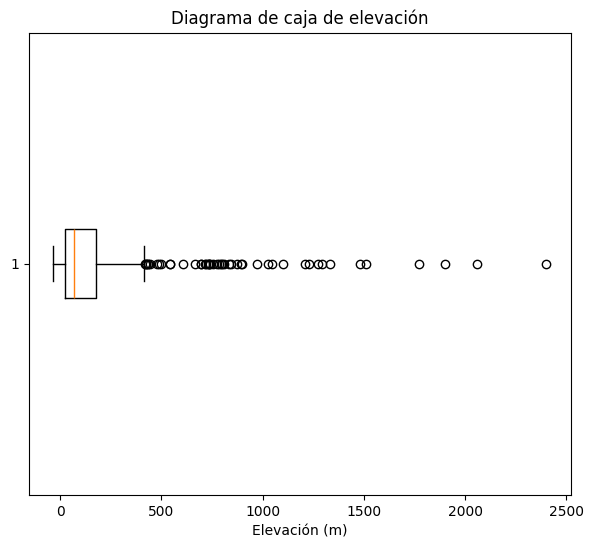

In [35]:
plt.figure(figsize=(7,6))
plt.boxplot(df["elevation_m"], vert=False)
plt.title("Diagrama de caja de elevación")
plt.xlabel("Elevación (m)")
plt.show()


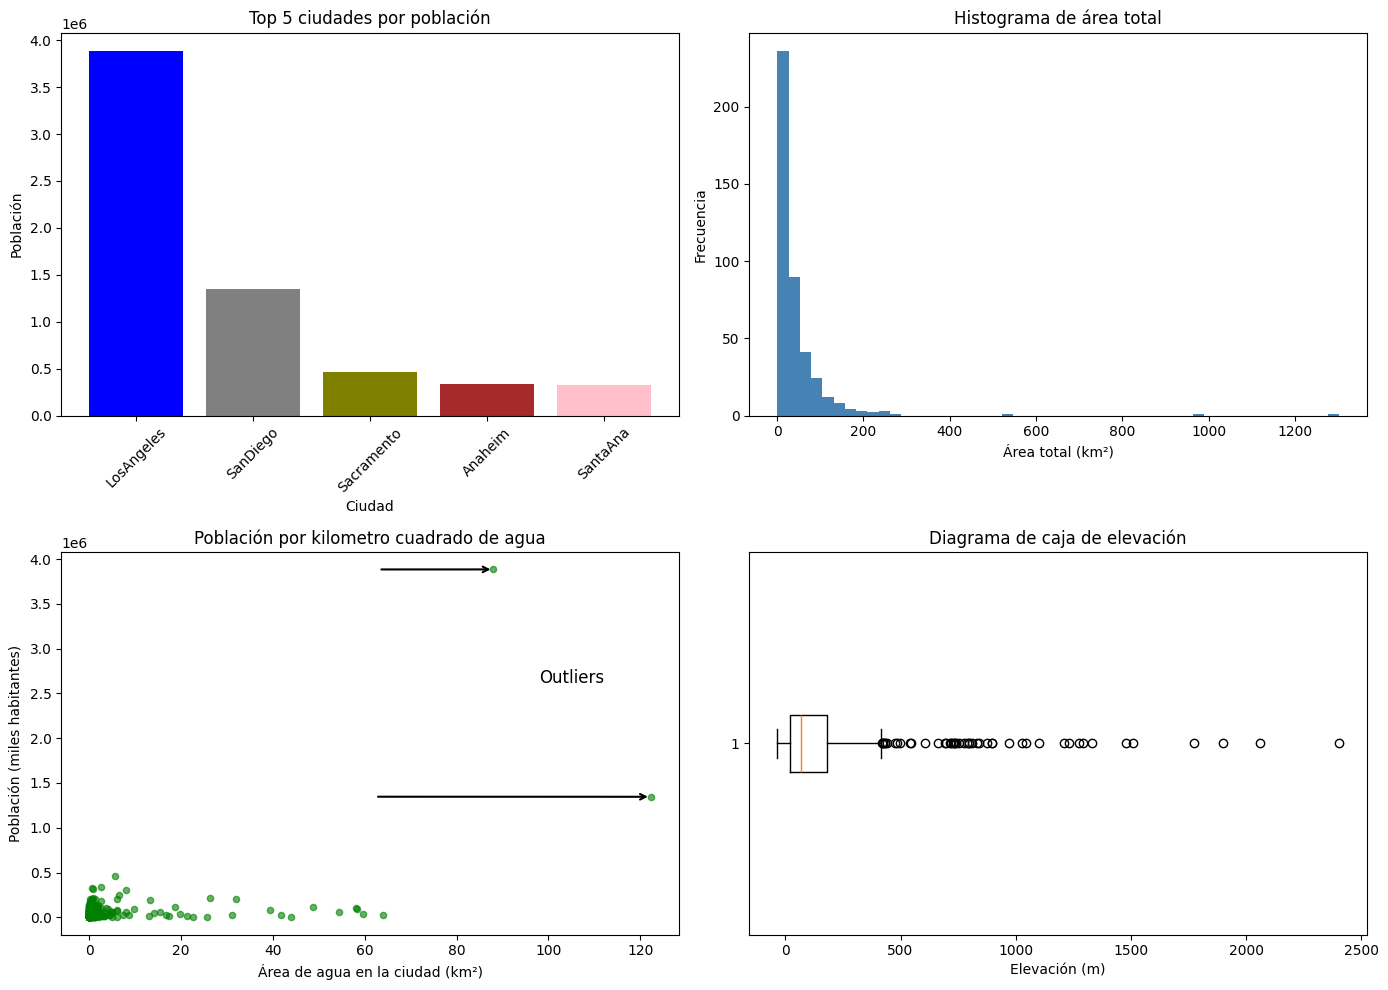

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

top5 = df.nlargest(5, "population_total")[["city", "population_total"]]
colores = ["blue", "gray", "olive", "brown", "pink"]

axes[0, 0].bar(top5["city"], top5["population_total"], color=colores)
axes[0, 0].set_title("Top 5 ciudades por población")
axes[0, 0].set_xlabel("Ciudad")
axes[0, 0].set_ylabel("Población")
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].hist(df["area_total_km2"], bins=50, color="steelblue")
axes[0, 1].set_title("Histograma de área total")
axes[0, 1].set_xlabel("Área total (km²)")
axes[0, 1].set_ylabel("Frecuencia")

ax = axes[1, 0]

ax.scatter(df["area_water_km2"], df["population_total"], s=20, color="green", alpha=0.6)

ax.set_xlabel("Área de agua en la ciudad (km²)")
ax.set_ylabel("Población (miles habitantes)")
ax.set_title("Población por kilometro cuadrado de agua")

punto_alto = df.loc[df["population_total"].idxmax()]
punto_derecha = df.loc[df["area_water_km2"].idxmax()]

ax.text(
    x = (punto_alto["area_water_km2"] + punto_derecha["area_water_km2"]) / 2,
    y = (punto_alto["population_total"] + punto_derecha["population_total"]) / 2 + 200,
    s = "Outliers",
    ha = "center",
    fontsize = 12
)

ax.annotate(
    "",
    xy = (punto_alto["area_water_km2"], punto_alto["population_total"]),
    xytext = (punto_alto["area_water_km2"] - 25, punto_alto["population_total"] - 300),
    arrowprops = dict(arrowstyle="->", color="black", lw=1.5)
)

ax.annotate(
    "",
    xy = (punto_derecha["area_water_km2"], punto_derecha["population_total"]),
    xytext = (punto_derecha["area_water_km2"] - 60, punto_derecha["population_total"] + 700),
    arrowprops = dict(arrowstyle="->", color="black", lw=1.5)
)

axes[1, 1].boxplot(df["elevation_m"], vert=False)
axes[1, 1].set_title("Diagrama de caja de elevación")
axes[1, 1].set_xlabel("Elevación (m)")

plt.tight_layout()
plt.show()


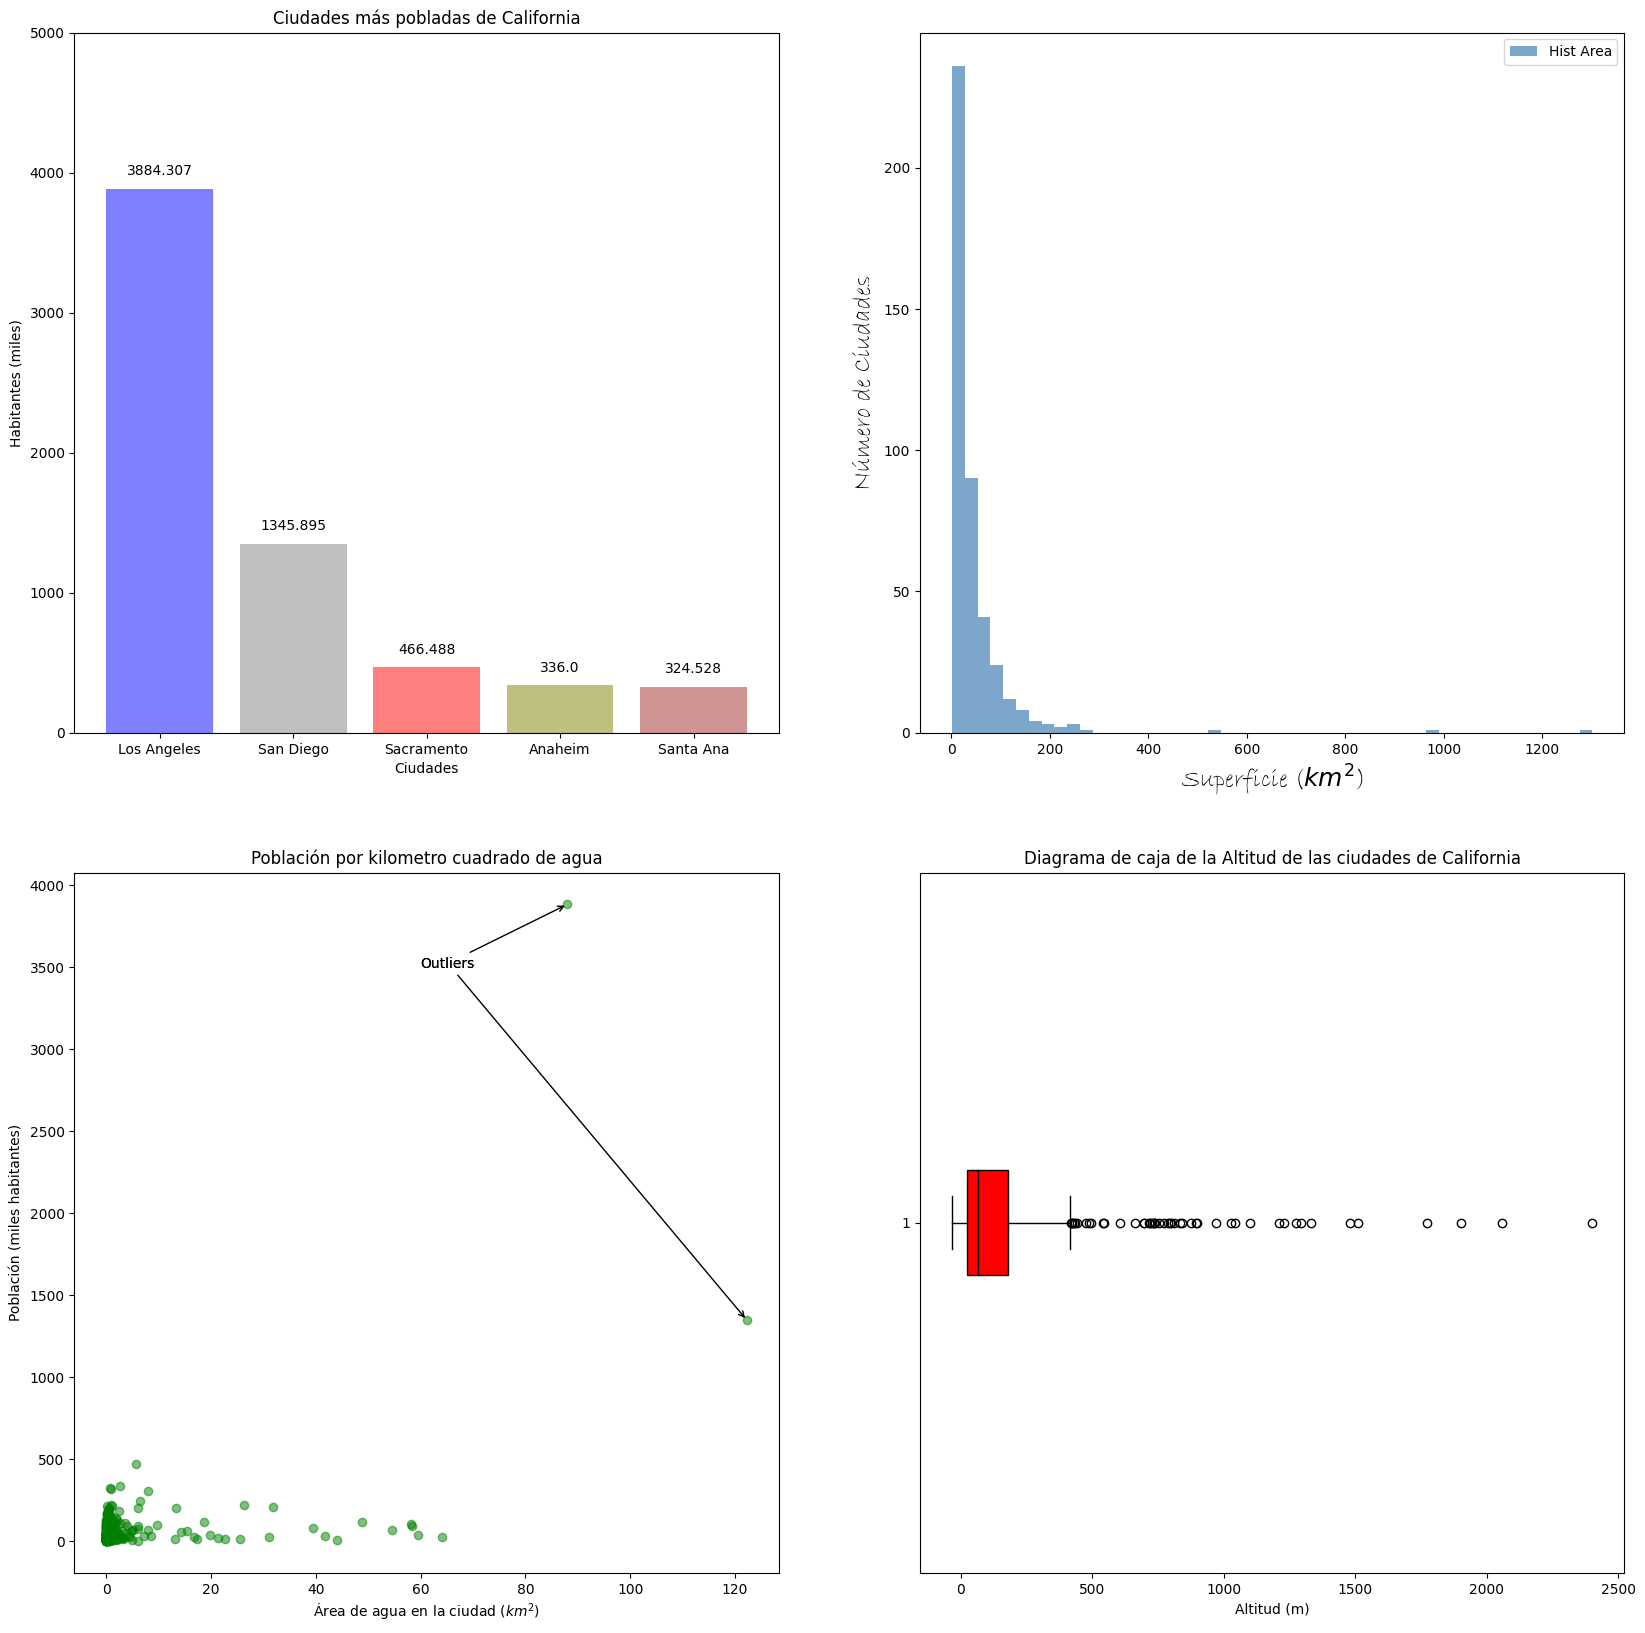

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

In [37]:
fig.savefig("visualizacion_california.png", dpi=300)